# Modules

In [ ]:
!pip install datasets
!pip install --upgrade huggingface_hub
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.3/553.3 kB 19.3 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.4.0
    Uninstalling huggingface_hub-1.4.0:
      Successfully uninstalled huggingface_hub-1.4.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 9.0 MB/s eta 0:00:00


In [ ]:
# Base --------------------------------------------------
import numpy as np
import pandas as pd
from itertools import islice

# Processing --------------------------------------------
import umap as UMAP
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

# PyTorch -----------------------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.functional import cross_entropy

# Transformers ------------------------------------------
from transformers import pipeline, AutoTokenizer, DistilBertTokenizer
from transformers import AutoModel, AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments

# Hugging Face -----------------------------------------
from huggingface_hub import login, list_datasets, notebook_login
from datasets import load_dataset

# Viz --------------------------------------------------
import matplotlib.pyplot as plt

# Huggingface Hub

Let's first login into the HuggingFace hub (you should have an account for this). As you will see in the prompt of the next function (list_datasets()), the login is not mandatory, but it is recommended

In [ ]:
# Login to HuggingFace
login()

I've also created an HF_TOKEN in the privacy configuration of this notebook so that I do not get a warning message when trying to access the datasets from it. Let's explore the datasets available within the Hugginface Hub

In [ ]:
all_datasets = list(list_datasets())
dataset_names = [dataset.id for dataset in islice(list_datasets(), 10)]

print(f'There are {len(all_datasets)} available on the hub')
print(f'The first 10 are {dataset_names}')

There are 834595 available on the hub
The first 10 are ['openbmb/UltraData-Math', 'sojuL/RubricHub_v1', 'tencent/CL-bench', 'FutureMa/EvasionBench', 'tencent/HY3D-Bench', 'Qwen/DeepPlanning', 'google/WaxalNLP', 'OpenMed/Medical-Reasoning-SFT-Trinity-Mini', 'perplexity-ai/draco', 'lxucs/tele-lens']


The `list_datasets()` returns a generator, that's why we called the datasets with the slice and the list comprehension.

Now let's load the "emotion" [dataset](https://huggingface.co/datasets/dair-ai/emotion) for the text classification task. The description of the data says "Emotion is a dataset of English Twitter messages with six basic emotions: anger, fear, joy, love, sadness, and surprise", and was used in the paper of Saravia et al. "Contextualized Affect Representations for Emotion Recognition" (2018), Proceedings of the 2018 Conference on Empirical Methods in Natural Language Processing.

In [ ]:
load_dataset('imdb')

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [ ]:
emotions = load_dataset('emotion')

README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

note that it has generated train/validation/test sets in the loading process

In [ ]:
emotions

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

 How do we access them? It is a dictionary, so we may use the usual procedures

In [ ]:
train = emotions['train']
train

Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})

and now the individual tweets can also be accessed by indexing

In [ ]:
train[0]

{'text': 'i didnt feel humiliated', 'label': 0}

The label is encoded by just a number, but in this case we also have access to the label name. You can see this by calling to the features of the data

In [ ]:
train.features

{'text': Value('string'),
 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])}

Now, to perform your classical EDA analysis (and do not get confused with the idea that since you'll be doing neural networks, you do not have to do EDA) you may feel better moving the data into a data frame and having the labl name within your variables.

In [ ]:
# Don't run: We are not doing EDA here and we need the previous dataset
emotions.set_format(type='pandas')
train_df = emotions['train'][:]

# Getting the names
def label_int2str(row):
    return emotions['train'].features['label'].int2str(row)

# Apply the function above
train_df['label_name'] = train_df['label'].apply(label_int2str)
train_df.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


# Tokenize

We are going to use the Auto classes from transformers, but you can always use the manual approach (we've added the DistilBertTokenizer as a loaded module)

In [ ]:
model_ckpt = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

you can access the tokens of the vocabulary and their ids as follows (we are just showing the first 4)

In [ ]:
list(tokenizer.vocab.items())[:4]

[('ginger', 14580), ('soy', 25176), ('[unused689]', 694), ('pendulum', 28300)]

Let's define a small function that applies the AutoTokenizer to a batch of examples. The options:

 * `padding=TRUE` will pad the examples with zeros to the size of the longest one
 * `truncate=TRUE` will truncate the examples to the model's maximum context size

In [ ]:
def tokenize(batch):
    return tokenizer(batch['text'], padding=True, truncation=True)

Let's see the output passed to two our our examples

In [ ]:
emotions['train'][:2]

{'text': ['i didnt feel humiliated',
  'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake'],
 'label': [0, 0]}

Use `tokenize` with the texts

In [ ]:
tokenize(emotions['train'][:2])

{'input_ids': [[101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}

in this output we see:

 * input_ids: these are the unique integer with which each unique token is encoded
 * attention_mask: let the classifier understand which parts of the vectors arise from padding

Now we are ready to apply it to the data

In [ ]:
emotions_encoded = emotions.map(tokenize, batched=True, batch_size=None)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

This has encoded the three datasets with the text, the labels, the input_ids, and the attention_mask values

In [ ]:
emotions_encoded.column_names

{'train': ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
 'validation': ['text',
  'label',
  'input_ids',
  'token_type_ids',
  'attention_mask'],
 'test': ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']}

# Training a Classifier

DistilBERT is one of the available pretrained models that are used to predict words in a sequence. However, they cannot be directly used for text classification and we need to modify them slightly.

Remember the chart for the encoder/decoder anaotmy? First the text is encoded, then embedded, passed to the encoder stack to get the hidden states which are passed on to make the predictions. What we are going to change is the language modeling layer with a classification layer, for this there are two options:

 * Feature extraction: use the hidden states as features and train a classifier on them, or
 * Fine-tuning: train the whole model, which updates the pretrained model too

## Feature Extraction

Let's define the model

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = AutoModel.from_pretrained(model_ckpt).to(device)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
def extract_hidden_states(batch):
    # Place model inputs on the GPU
    inputs = {k:v.to(device) for k,v in batch.items()
              if k in tokenizer.model_input_names}
    # Extract last hidden states
    with torch.no_grad():
        last_hidden_state = model(**inputs).last_hidden_state
    # Return vector for [CLS] token
    return {'hidden_state': last_hidden_state[:,0].cpu().numpy()}

since the function needs torch format, let's coerce our data to that

In [ ]:
emotions_encoded.set_format('torch',
                            columns=['input_ids', 'attention_mask', 'label'])

we can now get the hidden states using the model

In [ ]:
emotions_hidden = emotions_encoded.map(extract_hidden_states, batched=True)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
emotions_hidden['train'].column_names

['text',
 'label',
 'input_ids',
 'token_type_ids',
 'attention_mask',
 'hidden_state']

The idea now is to apply any classifier to these hidden states. For this we will follow every previous knowledge about classfiers and use Logistic Regression, Naïve Bayes, or whichever other method of your preference.

For this part we need the usual structure of train/validation

In [ ]:
X_train = np.array(emotions_hidden['train']['hidden_state'])
X_valid = np.array(emotions_hidden['validation']['hidden_state'])
y_train = np.array(emotions_hidden['train']['label'])
y_valid = np.array(emotions_hidden['validation']['label'])
X_train.shape, X_valid.shape

((16000, 768), (2000, 768))

Before the classification itself, let us plot the features in the training set. For this we need to project down the 768 dimensions down to 2. A powerful algorthm is UMAP (which works better when the features range from 0 to 1) then

In [ ]:
# Scale features to [0,1] range
X_scaled = MinMaxScaler().fit_transform(X_train)

# Initialize and fit UMAP
mapper = UMAP.UMAP(n_components=2, metric='cosine').fit(X_scaled)

# Create a DataFrame of 2D embeddings
df_emb = pd.DataFrame(mapper.embedding_, columns=['X', 'Y'])
df_emb['label'] = y_train
df_emb.head()

,X,Y,label
0,4.231274,3.179646,0
1,-3.295449,3.456133,0
2,4.825850,6.662223,3
3,-2.625160,5.566679,2
4,-3.579635,5.463635,3


Now we can plot the training set as

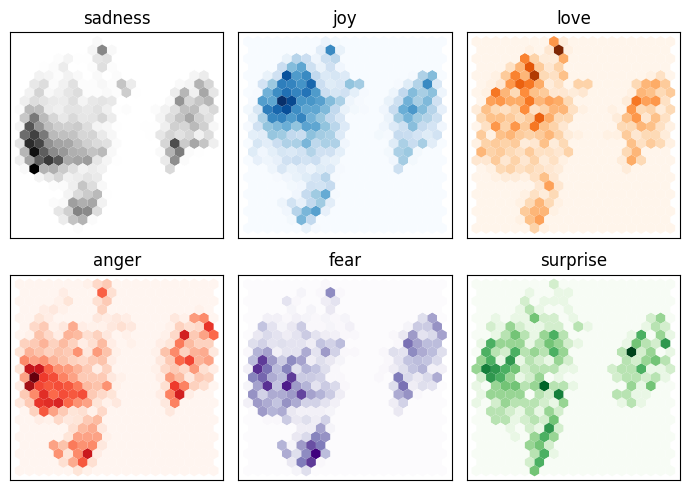

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(7,5))
axes = axes.flatten()
cmaps = ['Greys', 'Blues', 'Oranges', 'Reds', 'Purples', 'Greens']
labels = emotions['train'].features['label'].names

for i, (label, cmap) in enumerate(zip(labels, cmaps)):
    df_emb_sub = df_emb.query(f'label == {i}')
    axes[i].hexbin(df_emb_sub['X'], df_emb_sub['Y'], cmap=cmap,
                   gridsize=20, linewidths=(0,))
    axes[i].set_title(label)
    axes[i].set_xticks([]), axes[i].set_yticks([])

plt.tight_layout()
plt.show()

We can finally fit our classifier

In [ ]:
lr_clf = LogisticRegression(max_iter=3000)
lr_clf.fit(X_train, y_train)

LogisticRegression(max_iter=3000)

The accuracy we get is the following

In [ ]:
lr_clf.score(X_valid, y_valid)

0.6345

So it is just barely better than a random classifier. Let's see the confusion matrix

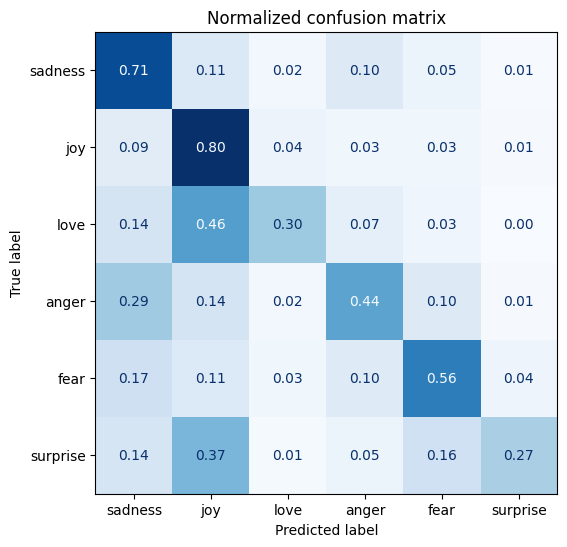

In [ ]:
def plot_confusion_matrix(y_preds, y_true, labels):
    cm = confusion_matrix(y_true, y_preds, normalize='true')
    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap='Blues', values_format='.2f', ax=ax, colorbar=False)
    plt.title('Normalized confusion matrix')
    plt.show()

y_preds = lr_clf.predict(X_valid)
plot_confusion_matrix(y_preds, y_valid, labels)

## Fine Tuning Transformers

Let's load a pretrained model

In [ ]:
num_labels = 6
model = (AutoModelForSequenceClassification
         .from_pretrained(model_ckpt, num_labels=num_labels)
         .to(device))

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


the warning is normal since the classification head has not yet been trained. Let's define the performance metrics for our model

In [ ]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    f1 = f1_score(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1}

Use the following line only if you want to push this notebook to your Huggingface Hub

In [ ]:
notebook_login()

Let's define the arguments of our trainer: number of epochs, learning rate,...

In [ ]:
batch_size = 64
logging_steps = len(emotions_encoded['train']) // batch_size
model_name = f'{model_ckpt}-finetuned-emotion'
training_args = TrainingArguments(output_dir=model_name,
                                  num_train_epochs=2,
                                  learning_rate=2e-5,
                                  per_device_train_batch_size=batch_size,
                                  per_device_eval_batch_size=batch_size,
                                  weight_decay=0.01,
                                  #evaluation_strategy='epoch',
                                  disable_tqdm=False,
                                  logging_steps=logging_steps,
                                  #push_to_hub=True,            # Uncomment if you want to push to HF
                                  log_level='error',
                                  report_to='none')             # drop the line to use wandb

Then we can train the model

In [ ]:
trainer = Trainer(model=model, args=training_args,
                  compute_metrics=compute_metrics,
                  train_dataset=emotions_encoded['train'],
                  eval_dataset=emotions_encoded['validation'],
                  #tokenizer=tokenizer
                  )
trainer.train()

Step,Training Loss
250,0.838191
500,0.260790


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=500, training_loss=0.5494903259277344, metrics={'train_runtime': 236.3231, 'train_samples_per_second': 135.408, 'train_steps_per_second': 2.116, 'total_flos': 720342861696000.0, 'train_loss': 0.5494903259277344, 'epoch': 2.0})

Now we can see all of our performance metrics as

In [ ]:
preds_output = trainer.predict(emotions_encoded["validation"])
preds_output.metrics

{'test_loss': 0.22334475815296173,
 'test_accuracy': 0.9235,
 'test_f1': 0.923444228289945,
 'test_runtime': 3.9738,
 'test_samples_per_second': 503.301,
 'test_steps_per_second': 8.053}

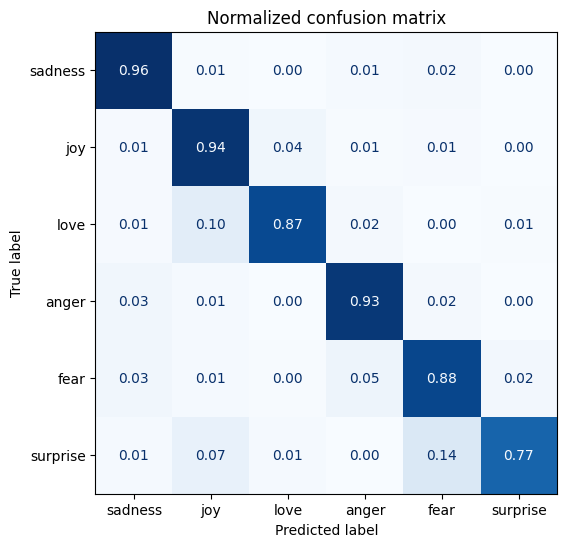

In [ ]:
y_preds = np.argmax(preds_output.predictions, axis=1)
plot_confusion_matrix(y_preds, y_valid, labels)